In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("car_age_price.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (112, 2)


,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [3]:
print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB

Missing values:


Year     0
Price    0
dtype: int64


Descriptive statistics:


,Year,Price
count,112.000000,112.000000
mean,2016.669643,483866.044643
std,1.629616,91217.450533
min,2013.000000,300000.000000
25%,2015.000000,423750.000000
50%,2017.000000,500000.000000
75%,2017.000000,550000.000000
max,2020.000000,755000.000000


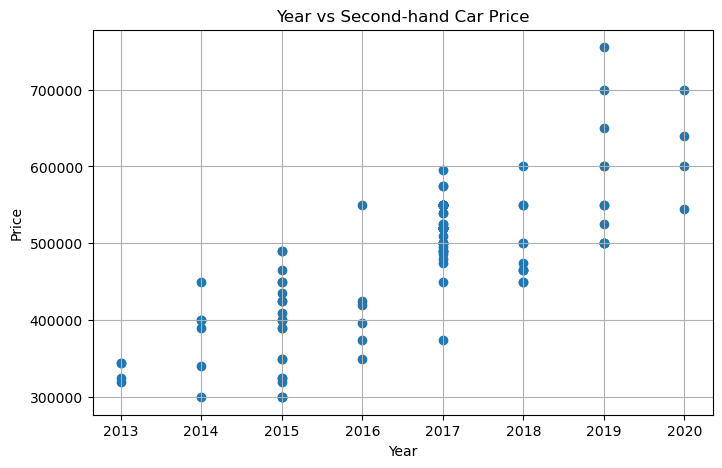

The plot shows a generally positive relationship between car year and price.


In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Year"], df["Price"])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Second-hand Car Price")
plt.grid(True)
plt.show()

print("The plot shows a generally positive relationship between car year and price.")

In [5]:
X = df[["Year"]]
y = df["Price"]

print("Independent variable (X): Year")
print("Dependent variable (y): Price")
print("X shape:", X.shape)
print("y shape:", y.shape)

Independent variable (X): Year
Dependent variable (y): Price
X shape: (112, 1)
y shape: (112,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
display(X_train.head())

Training samples: 89
Testing samples: 23


,Year
66,2017
90,2017
62,2017
22,2015
85,2015


In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained.")
print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)
print(
    f"Regression equation: Price = {linear_model.coef_[0]:.2f} × Year "
    f"+ ({linear_model.intercept_:.2f})"
)

Linear Regression model trained.
Coefficient: 47608.567808076594
Intercept: -95520922.49198583
Regression equation: Price = 47608.57 × Year + (-95520922.49)


In [8]:
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

linear_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [linear_mae, linear_rmse, linear_r2]
})

display(linear_results)

,Metric,Linear Regression
0,MAE,53534.779570
1,RMSE,65779.223596
2,R² Score,0.367593


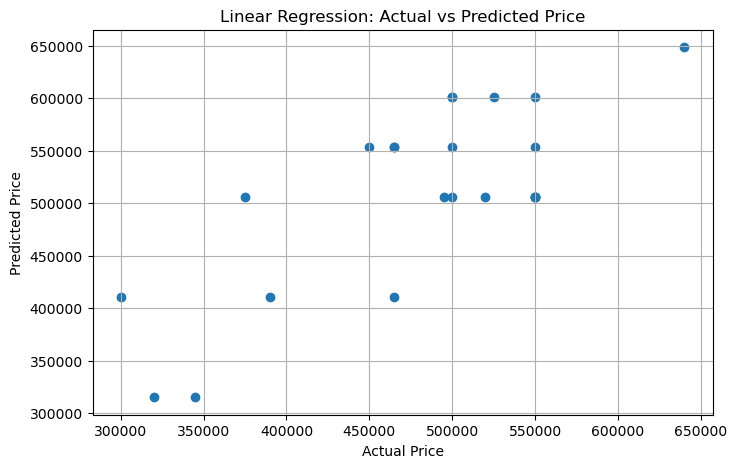

Closer clustering around the ideal relationship indicates better predictions.


In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, linear_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Price")
plt.grid(True)
plt.show()

print("Closer clustering around the ideal relationship indicates better predictions.")

## Lasso Regression

In [10]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

print("Lasso Regression model trained.")
print("Alpha:", lasso_model.alpha)
print("Coefficient:", lasso_model.coef_[0])
print("Intercept:", lasso_model.intercept_)
print(
    f"Regression equation: Price = {lasso_model.coef_[0]:.2f} × Year "
    f"+ ({lasso_model.intercept_:.2f})"
)

Lasso Regression model trained.
Alpha: 1.0
Coefficient: 47608.15559950043
Intercept: -95520091.24791843
Regression equation: Price = 47608.16 × Year + (-95520091.25)


In [11]:
lasso_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

lasso_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Lasso Regression": [lasso_mae, lasso_rmse, lasso_r2]
})

display(lasso_results)

,Metric,Lasso Regression
0,MAE,53534.330309
1,RMSE,65778.870247
2,R² Score,0.367600


In [12]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [linear_mae, linear_rmse, linear_r2],
    "Lasso Regression": [lasso_mae, lasso_rmse, lasso_r2]
})

display(comparison)

print("For MAE and RMSE, lower values are better.")
print("For R² Score, higher values are better.")

,Metric,Linear Regression,Lasso Regression
0,MAE,53534.779570,53534.330309
1,RMSE,65779.223596,65778.870247
2,R² Score,0.367593,0.367600


For MAE and RMSE, lower values are better.
For R² Score, higher values are better.


In [13]:
# Train both models on the complete dataset for the final 2022 estimate.
linear_final = LinearRegression().fit(X, y)
lasso_final = Lasso(alpha=1.0, max_iter=10000).fit(X, y)

year_2022 = pd.DataFrame({"Year": [2022]})

linear_2022_price = linear_final.predict(year_2022)[0]
lasso_2022_price = lasso_final.predict(year_2022)[0]

prediction = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression"],
    "Predicted 2022 Price (₹)": [linear_2022_price, lasso_2022_price]
})

display(prediction)

print(f"Linear Regression estimated 2022 price: ₹{linear_2022_price:,.2f}")
print(f"Lasso Regression estimated 2022 price: ₹{lasso_2022_price:,.2f}")

,Model,Predicted 2022 Price (₹)
0,Linear Regression,715488.078510
1,Lasso Regression,715486.053249


Linear Regression estimated 2022 price: ₹715,488.08
Lasso Regression estimated 2022 price: ₹715,486.05


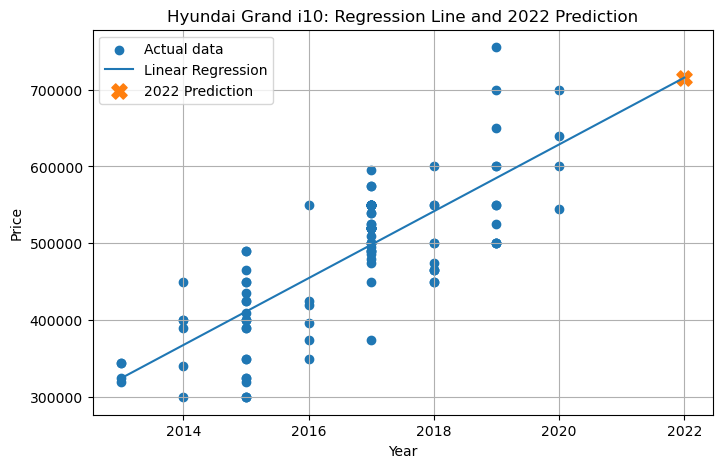

The regression line is extended to 2022 to show the estimated price.


In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Year"], df["Price"], label="Actual data")

years = np.linspace(df["Year"].min(), 2022, 200)
year_df = pd.DataFrame({"Year": years})
prices = linear_final.predict(year_df)

plt.plot(years, prices, label="Linear Regression")
plt.scatter([2022], [linear_2022_price], marker="X", s=120, label="2022 Prediction")

plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Hyundai Grand i10: Regression Line and 2022 Prediction")
plt.legend()
plt.grid(True)
plt.show()

print("The regression line is extended to 2022 to show the estimated price.")